<a href="https://colab.research.google.com/github/aramakrishnan-nn/makemore-characterbigram/blob/main/character_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [164]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [165]:
list_of_words = open('names.txt', 'r').read().splitlines()
words = [word.lower() for word in list_of_words]

words[:10]

['aadarsh',
 'aaditya',
 'aarav',
 'aaryan',
 'abhay',
 'abhigyan',
 'abhijeet',
 'abhijit',
 'abhilash',
 'abhimanyu']

In [166]:
#Shortest Word
min(len(w) for w in words)

2

In [167]:
#Longest Word
max(len(w) for w in words)

15

In [168]:
#Bigram Model -> Looking at 2 characters at a time
#Given a character, the idea is to predict the second character


In [169]:
#Dictionary for keeping counts of the bigrams

b = {}

for w in words:
  chs = '#' + w + '%'
  for c1, c2 in zip(chs, chs[1:]):
    bigram = (c1, c2)
    b[bigram] = b.get(bigram, 0) + 1

    #print(c1, c2)

#b

In [170]:
#Printing top 10
sorted(b.items(), key = lambda kv: -kv[1])[:10]

[(('n', '%'), 6814),
 (('a', '%'), 6692),
 (('a', 'n'), 5538),
 (('#', 'a'), 4470),
 (('e', '%'), 3984),
 (('a', 'r'), 3312),
 (('e', 'l'), 3249),
 (('r', 'i'), 3049),
 (('n', 'a'), 3003),
 (('#', 'k'), 2987)]

In [171]:
#Moving to an 3 D array
#Row -> 1st Character
#Col -> tells us about the 2nd character that follows

In [172]:
#It needs to be (28, 28) and not (26, 26)
#as we have added two special characters for start and end
N = torch.zeros((28, 28), dtype = torch.int32)

In [173]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['#'] = 0

print(stoi)
itos = {i:s for s, i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '#': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '#'}


In [174]:
for w in words:
  chs = '#' + w + '#'
  for c1, c2 in zip(chs, chs[1:]):
    ix1 = stoi[c1]
    ix2 = stoi[c2]

    N[ix1, ix2] += 1


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

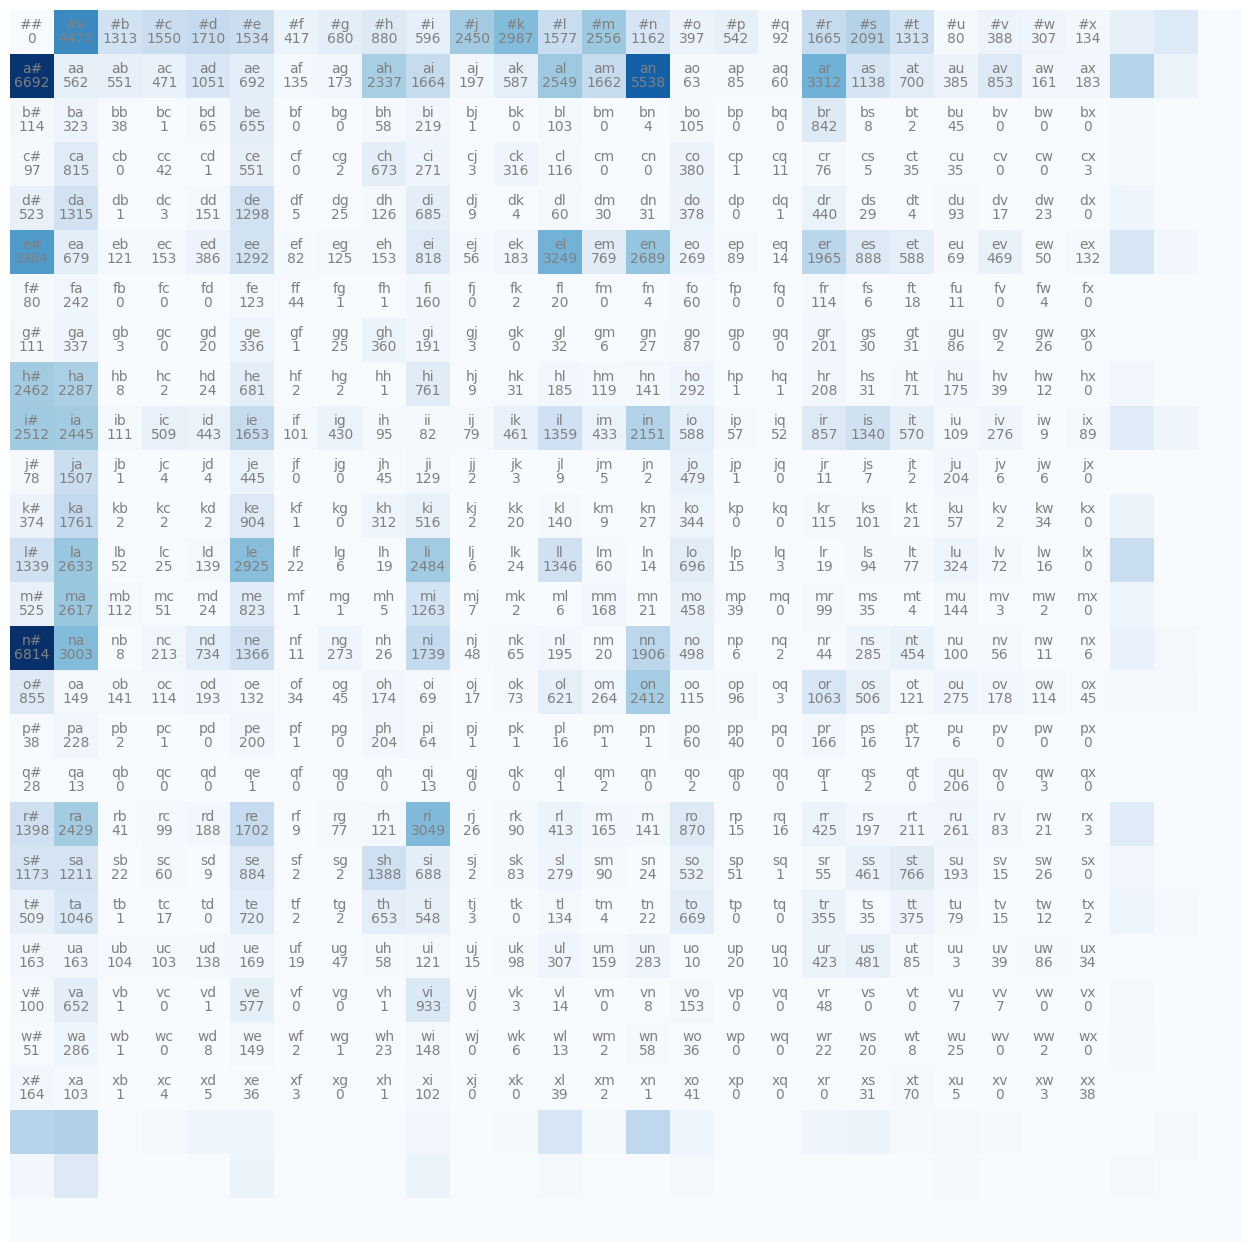

In [175]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap = 'Blues')

for i in range(25):
  for j in range(25):
    chstr = itos[i] + itos[j]
    plt.text(j, i, chstr, ha = 'center', va = 'bottom', color = 'gray')
    plt.text(j, i, N[i, j].item(), ha = 'center', va = 'top', color = 'gray')

plt.axis('off')

In [176]:
N[0, :].shape

torch.Size([28])

In [177]:
#Creating the Probability Vector
#Converting from raw counts to probabilities
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1381, 0.0406, 0.0479, 0.0528, 0.0474, 0.0129, 0.0210, 0.0272,
        0.0184, 0.0757, 0.0923, 0.0487, 0.0790, 0.0359, 0.0123, 0.0168, 0.0028,
        0.0515, 0.0646, 0.0406, 0.0025, 0.0120, 0.0095, 0.0041, 0.0166, 0.0287,
        0.0000])

In [178]:
#Picking out the character after sampling
g = torch.Generator().manual_seed(19471950)
index = torch.multinomial(p, num_samples=1, replacement=True, generator = g).item()
itos[index]

'l'

In [179]:
# Making the probabilities Matrix
# Adding 1 to ensure that we don't have zero probability for any combination
# Given that this is added to everything, it doesn't change the outcome; It is "Model Smoothing"
P = (N +1).float()

# Converting it to a 25,1 Column Vector
P /= P.sum(1, keepdims = True)

# Read about Broadcasting rules
# 25, 25
# 25, 1 The system copies the values into the second
# dimension to match & make it 25 values

In [180]:
# Information; No actual calculation is happening here

print(P.sum(1, keepdims = True).shape)

# If you remove keepdims = True, then the shape goes wrong.
# 1, 25 will become a row vector; This gets copied 25 times
# The division gets normalized by columns and not rows

torch.Size([28, 1])


In [181]:
# Though the output is terrible,
# the code is correct :)

g = torch.Generator().manual_seed(78194719500)

for i in range(10):
  out = []
  index = 0
  while True:
    p = P[index]
    #p = N[index].float()
    #p = p / p.sum()
    #p = torch.ones(25)/25.0
    index = torch.multinomial(p, num_samples=1, replacement=True, generator = g).item()
    out.append(itos[index])
    if index == 0:
      break;

  print(''.join(out))


ka#
howneli#
wn#
miubramulipaby#
kayuryah#
marela#
avihatticona#
ta#
y#
r#


In [182]:
# Maximum Likelihood Estimation
# Log Likelihood
# Goal is to minimize the negative log likelihood

log_likelihood = 0.0
count = 0.0

for w in words:
  chars = '#' + w + '#'
  for c1, c2 in zip(chars, chars[1:]):
    index1 = stoi[c1]
    index2 = stoi[c2]
    probability = P[index1, index2]
    log_probability = torch.log(probability)
    log_likelihood += log_probability
    count += 1
    #print(f'{c1}{c2}: {probability: .5f} {log_probability: .4f} {log_likelihood: .4f}')

neg_log_likelihood = - log_likelihood
print(f'negative log likelihood {neg_log_likelihood: .4f}')
normalized_neg_log_likelihood = neg_log_likelihood / count
print(f'Normalized {normalized_neg_log_likelihood: .4f}')

negative log likelihood  566008.3750
Normalized  2.4557


In [183]:
# Alternative
# Getting to the NN Framework

# Creating training set
xs, ys = [], []

for w in words:
  chars = '#' + w + '#'
  for c1, c2 in zip(chars, chars[1:]):
    index1 = stoi[c1]
    index2 = stoi[c2]
    xs.append(index1)
    ys.append(index2)
    #print(c1, c2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('Number of examples: ', num)

#print('xs', xs)
#print('ys', ys)


Number of examples:  230487


In [184]:
# One Hot Encoding
import torch.nn.functional as F
x_encoded = F.one_hot(xs, num_classes=27).float()
print(x_encoded.shape)
print(x_encoded.dtype)
#plt.imshow(x_encoded)

torch.Size([230487, 27])
torch.float32


In [185]:
# Constructing the Neuron

g = torch.Generator().manual_seed(200304202526)

W = torch.randn((27,27), requires_grad=True, generator=g)

# Matrix Multiplication
net_mul = x_encoded @ W

# This tell us the probability of a specific value
# appearing for the first 8 combinations
# Reason we run it on all 27 is due to the fact that,
# we should build for any possibility

print(net_mul.shape)
#print(net_mul)

print('x_encoded of [3]', x_encoded[3])
print('net_mul of [3]', net_mul[3])

# The x_encoded[3] is 'd' and as per the info above the value next to 'd' is 'a'.
# In the tensor info below, it is clear that the system thinks that next to 'd',
# it will be the second character in the One hot Encoded Table that we have.
# This should be correcponding to the second character in the table after '#'.



torch.Size([230487, 27])
x_encoded of [3] tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])
net_mul of [3] tensor([ 1.1527,  0.7036, -1.4029, -0.4671,  0.5143, -0.4490, -0.0556,  0.0157,
        -0.5313, -1.4327,  0.9255,  1.4889,  1.1737, -0.1873,  1.4330, -0.7888,
         0.2683, -0.0319,  0.0852,  0.5418, -0.1410, -1.3807, -0.6143, -0.5826,
         0.2230,  0.2185, -0.1556], grad_fn=<SelectBackward0>)


In [186]:
# Forward Pass
x_encoded = F.one_hot(xs, num_classes=27).float()
logits = x_encoded @ W

# Negative numbers go below 1
# Quantum of positive number increases

# This is Softmax activation
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
# Handling Loss Function
#loss = -probs[torch.arange(22), ys].log().mean()
#print(loss)


In [187]:
print(probs.shape)
print(probs[0].sum())
print(probs[0].shape)

torch.Size([230487, 27])
tensor(1., grad_fn=<SumBackward0>)
torch.Size([27])


In [188]:
# Backward Pass
W.grad = None # Set to zero

#loss.backward()
#print(loss.item())


In [189]:
# Updating the tensor
#W.data += -0.1 * W.grad

In [192]:
for k in range(100):
  #forward pass
  x_encoded = F.one_hot(xs, num_classes=27).float()
  logits = x_encoded @ W

  # Negative numbers go below 1
  # Quantum of positive number increases

  # This is Softmax activation
  counts = logits.exp()
  probs = counts / counts.sum(1, keepdims=True)
  # Handling Loss Function
  loss = -probs[torch.arange(num), ys].log().mean() + 0.1 * (W**2).mean()
  print(loss.item())
  #backward pass
  W.grad = None # Set to zero

  loss.backward()

  #Update
  W.data += -8 * W.grad



2.6436688899993896
2.6431119441986084
2.6425654888153076
2.642028331756592
2.641500949859619
2.640981674194336
2.640470504760742
2.639967679977417
2.639472484588623
2.638984441757202
2.638503074645996
2.638028621673584
2.6375606060028076
2.637099266052246
2.636643886566162
2.6361942291259766
2.6357507705688477
2.635312795639038
2.634880304336548
2.634453058242798
2.634030818939209
2.6336145401000977
2.63320255279541
2.6327953338623047
2.6323933601379395
2.631995916366577
2.6316030025482178
2.6312146186828613
2.630830764770508
2.630450963973999
2.630075693130493
2.629704475402832
2.6293373107910156
2.628974676132202
2.628615379333496
2.6282598972320557
2.627908706665039
2.627561092376709
2.6272168159484863
2.6268765926361084
2.626539707183838
2.626206874847412
2.6258773803710938
2.6255507469177246
2.625227689743042
2.624908447265625
2.624591827392578
2.6242787837982178
2.623969078063965
2.6236624717712402
2.623358726501465
2.6230578422546387
2.6227598190307617
2.6224653720855713
2.62217

In [198]:
g = torch.Generator().manual_seed(200304202526)

for i in range(20):
  out = []
  ix = 0
  while True:
    x_encoded = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = x_encoded @ W
    counts = logits.exp()
    p = counts / counts.sum(1, keepdims=True)
    ix = torch.multinomial(p, num_samples=1, replacement = True).item()
    out.append(itos[ix])
    if ix == 0:
      break;
  print(''.join(out))

ch#
ae#
kcacarahgvto#
a#
eiorian#
chaliphayniliof#
anadokan#
gvan#
kgranainan#
gri#
aqmxkarrirahezera#
merall#
kyayda#
stegelenn#
bra#
sach#
bryjaan#
thamaker#
inilao#
h#
